In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv("console_nintendo_famicom_nes.csv")

# View first rows
df.head()

,Screen title @ Exact,Cover title @ Exact,ID,Region,Release date,Developer,Publisher,Tags,MD5,SHA1,SHA256,SHA512
0,4 Nin Uchi Mahjong@4人打ち麻雀,4 Nin Uchi Mahjong@4人打ち麻雀,4ninuchimahjong,Japan,1984-11-02,Hudson,Nintendo,#players:1 #genre:board>mahjong #lang:ja,44f219c48d7b62798d814efacf164865,ea172299af323a27177c897cf340e3544ef3d089,6a41f126b401cda0fc751981f586f8e67dfa9156a4aa2c...,0d6b668d68e3604ed38c887ab6526f7e37a7134029bb96...
1,4 Nin Uchi Mahjong@4人打ち麻雀,4 Nin Uchi Mahjong@4人打ち麻雀,4ninuchimahjong,Japan,NaN,Hudson,Nintendo,#players:1 #genre:board>mahjong #lang:ja #rev:1,6d106b111eb177010329f7778468f79d,15efa139e1ffdb8c35c400dcbb775b86bff80103,13f795d3a8588175f065649fe9954950c775f1b8e59d8a...,b2c2ff1e0f842afe7107c3c9c3bd31458dfb3b93171ee3...
2,8 Eyes@8 Eyes エイト アイズ,8 Eyes@8 Eyes エイト・アイズ,8eyes,Japan,1988-09-27,Thinking Rabbit,SETA,#players:2:coop #genre:action>platformer #save...,f0629c17b2de7ab1d5f0c434f0588c7e,a6e7be3bff296d0028597cba0510ef9690b3cab6,1dafe2652523b8fcd37905da701dcf05f7bc36f466b33d...,1ec4504792d1daa72b90d72737997d8c8fb8546cec812e...
3,10-Yard Fight,10-Yard Fight@10-Yard Fight 10ヤードファイト,10yardfight,Japan,1985-08-30,Irem,Irem,#players:2:vs #genre:sports>football #port:arc...,1378270f6cf90095b7fea1e6648503a4,2a91760c828b26adc765ba9b0322fb770089e391,82e8e0cc827e061ff9d5707ec60a2658acbd47814b29ab...,ed94f740ef2969cad2bdc8ef21ebf238ea5fc0f1a7a53c...
4,10-Yard Fight,10-Yard Fight@10-Yard Fight 10ヤードファイト,10yardfight,Japan,NaN,Irem,Irem,#players:2:vs #genre:sports>football #port:arc...,1e2ec36ed66519dd03a52f1847e9d56d,5b073d8dfffe1fef85a047c2b7b063f9451c9350,7861d4e443dd02d9c06442d135ce64c098b772359a9470...,b1ca7bc76dc6115ccaa35e56dd8fe2aa26ac3bbd51e688...


In [3]:
# Check structure
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3137 entries, 0 to 3136
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Screen title @ Exact  3137 non-null   str  
 1   Cover title @ Exact   3061 non-null   str  
 2   ID                    3136 non-null   str  
 3   Region                3137 non-null   str  
 4   Release date          2791 non-null   str  
 5   Developer             3136 non-null   str  
 6   Publisher             3131 non-null   str  
 7   Tags                  3137 non-null   str  
 8   MD5                   3134 non-null   str  
 9   SHA1                  3134 non-null   str  
 10  SHA256                3134 non-null   str  
 11  SHA512                3134 non-null   str  
dtypes: str(12)
memory usage: 1.6 MB


Screen title @ Exact      0
Cover title @ Exact      76
ID                        1
Region                    0
Release date            346
Developer                 1
Publisher                 6
Tags                      0
MD5                       3
SHA1                      3
SHA256                    3
SHA512                    3
dtype: int64

In [6]:
df.columns.tolist()

['Screen title @ Exact',
 'Cover title @ Exact',
 'ID',
 'Region',
 'Release date',
 'Developer',
 'Publisher',
 'Tags',
 'MD5',
 'SHA1',
 'SHA256',
 'SHA512']

In [8]:
df.columns = df.columns.str.lower()

In [12]:
from sklearn.model_selection import train_test_split

# Example feature data and labels
X = [[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]]
y = [0, 1, 0, 1, 0]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



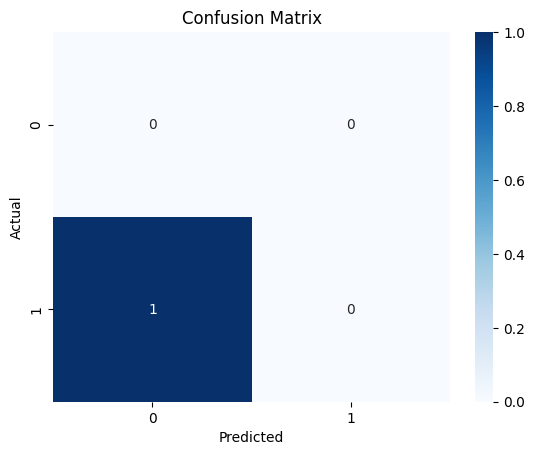

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
print("Features:", len(features))
print("Coefficients:", len(model.coef_[0]))
print(model.coef_.shape)

Features: 4
Coefficients: 2
(1, 2)
